# LabSheet - 5
### Name - Saurabh Kumar Jha
### CUID - CU24250005
### Program - B.Tech - CSE

In [4]:
import cv2
import numpy as np
from skimage import data, color, transform
from skimage.feature import hog
from skimage.util import img_as_ubyte
import matplotlib.pyplot as plt

In [5]:
image_rgb = data.astronaut()
gray = color.rgb2gray(image_rgb)
gray_u8 = img_as_ubyte(gray)

In [6]:
sift = cv2.SIFT_create()
keypoints, sift_descriptors = sift.detectAndCompute(gray_u8, None)

sift_visualization = cv2.drawKeypoints(
    gray_u8,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

In [7]:
hog_features, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True
)

In [8]:

rotated = transform.rotate(image_rgb, angle=15, resize=False)
rotated_gray = img_as_ubyte(color.rgb2gray(rotated))

keypoints_rotated, descriptors_rotated = sift.detectAndCompute(
    rotated_gray, None
)

matches_image = None

if sift_descriptors is not None and descriptors_rotated is not None:
    matcher = cv2.BFMatcher()
    knn_matches = matcher.knnMatch(
        sift_descriptors,
        descriptors_rotated,
        k=2
    )

    good_matches = [
        m for m, n in knn_matches
        if m.distance < 0.7 * n.distance
    ]

    matches_image = cv2.drawMatches(
        gray_u8,
        keypoints,
        rotated_gray,
        keypoints_rotated,
        good_matches[:50],
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

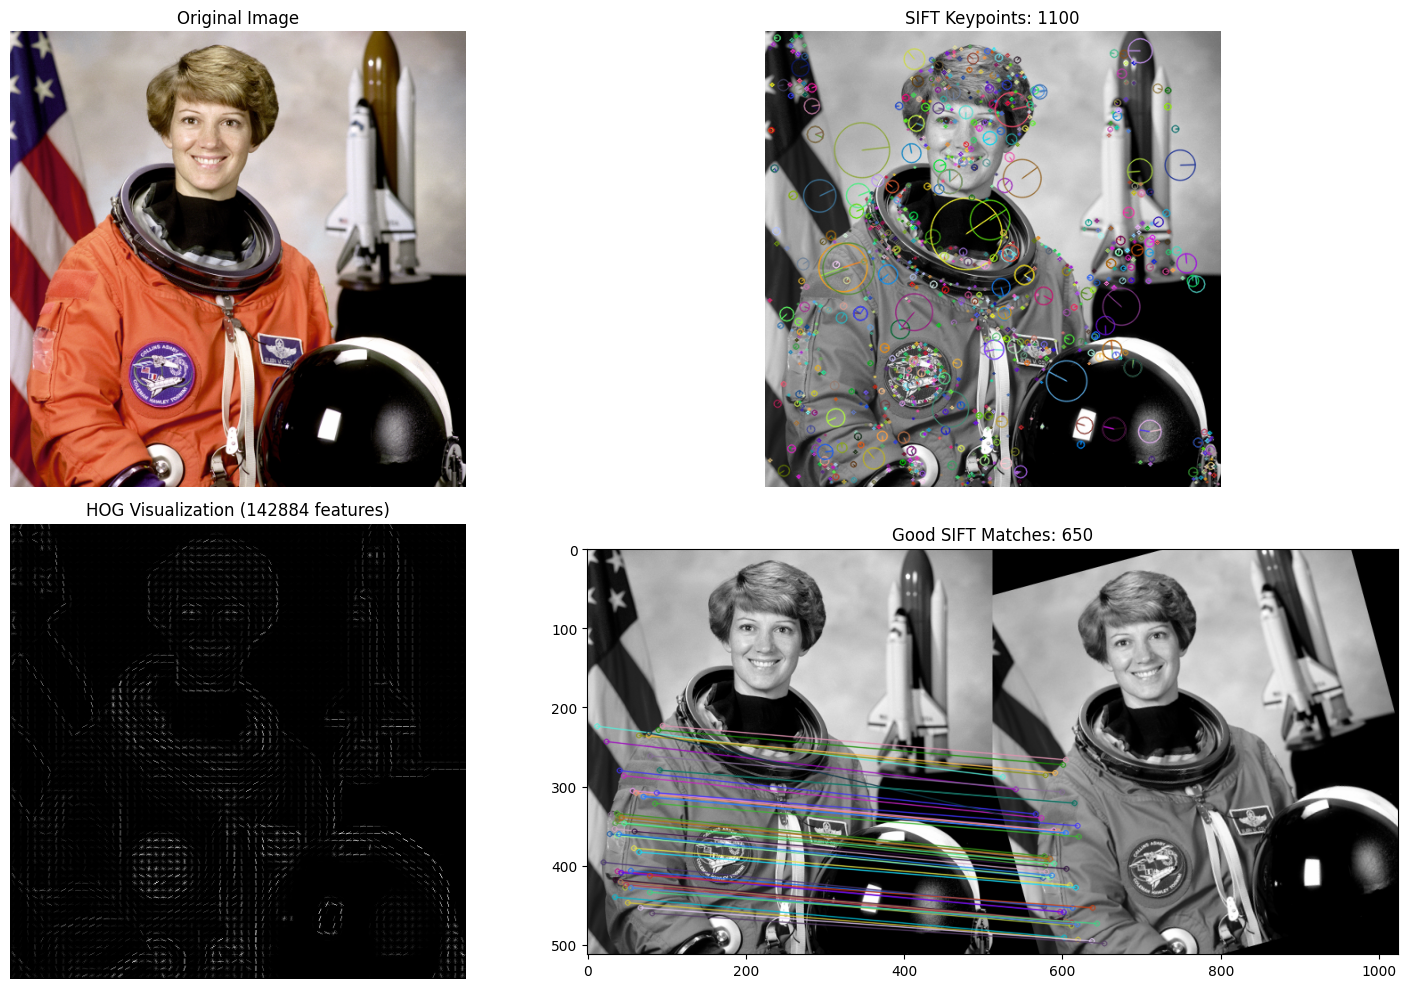

In [9]:

plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(cv2.cvtColor(sift_visualization, cv2.COLOR_BGR2RGB))
plt.title(f"SIFT Keypoints: {len(keypoints)}")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(hog_image, cmap="gray")
plt.title(f"HOG Visualization ({len(hog_features)} features)")
plt.axis("off")

plt.subplot(2, 2, 4)
if matches_image is not None:
    plt.imshow(cv2.cvtColor(matches_image, cv2.COLOR_BGR2RGB))
    plt.title(f"Good SIFT Matches: {len(good_matches)}")
else:
    plt.text(0.5, 0.5, "Descriptors unavailable", ha="center", va="center")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
print("SIFT descriptor shape:", None if sift_descriptors is None else sift_descriptors.shape)
print("HOG descriptor shape:", hog_features.shape)

SIFT descriptor shape: (1100, 128)
HOG descriptor shape: (142884,)


## Answers: SIFT and HOG Feature Extraction

### 1. What is feature extraction, and why is it important?

Feature extraction converts an image into measurable characteristics such as edges, corners, shapes, textures, and gradients. It reduces the amount of data while retaining important visual information. This improves the speed and accuracy of image classification, matching, recognition, and object detection.

### 2. Explain the working principle of SIFT.

SIFT (Scale-Invariant Feature Transform) works by:

1. Building a scale space using blurred versions of the image.
2. Detecting keypoints as extrema in Difference-of-Gaussian images.
3. Assigning an orientation to each keypoint.
4. Generating a descriptor from local gradient directions and magnitudes around each keypoint.
5. Matching descriptors between images using distance measures such as Euclidean distance.

### 3. What are keypoints and feature descriptors?

Keypoints are distinctive image locations, such as corners or textured regions, that can be reliably detected. A feature descriptor is a numerical representation of the local image region surrounding a keypoint. SIFT descriptors are generally 128-dimensional vectors.

### 4. Explain HOG and its significance.

Histogram of Oriented Gradients (HOG) represents an image using the distribution of edge directions. The image is divided into small cells, gradient orientations are accumulated into histograms, and neighboring cells are normalized in blocks.

HOG is significant because object shapes and silhouettes are strongly represented by their edges. It is especially effective for detecting objects with relatively stable shapes.

### 5. Compare SIFT and HOG.

| Property | SIFT | HOG |
|---|---|---|
| Main information | Local keypoints and texture | Global/local edge structure |
| Scale robustness | Strong | Limited unless images are resized |
| Rotation robustness | Strong due to orientation assignment | Limited |
| Illumination robustness | Good | Good after normalization |
| Computational complexity | Relatively high | Usually lower |
| Output | Variable number of descriptors | Fixed-length descriptor |
| Applications | Image matching, panorama creation, object recognition | Pedestrian detection, vehicle detection, shape classification |

### 6. Why is SIFT invariant to scale and rotation?

SIFT detects keypoints across multiple image scales using a scale-space representation. It assigns each keypoint a dominant gradient orientation. The descriptor is then calculated relative to that scale and orientation, making it largely invariant to image resizing and rotation.

### 7. Three real-world applications of HOG

1. Pedestrian detection in surveillance and autonomous vehicles.
2. Vehicle and cyclist detection in traffic-monitoring systems.
3. Human or object shape detection in robotics and security systems.

### 8. Why perform feature extraction before classification or detection?

Raw images contain many pixels, redundancy, noise, and irrelevant information. Feature extraction produces compact and meaningful representations. This reduces computational cost, improves learning efficiency, and can make patterns easier for a classifier or detector to distinguish.

### 9. Advantages and limitations of handcrafted descriptors

**Advantages:**

- Require less training data.
- Often computationally efficient.
- Easier to interpret.
- Useful when the image domain is known and controlled.
- Can work well with traditional machine-learning algorithms.

**Limitations:**

- Depend on manually designed assumptions.
- May perform poorly under large variations in viewpoint, illumination, occlusion, or deformation.
- Usually less adaptable than deep-learning features.
- Require separate design and tuning for different tasks.

Deep-learning methods can learn task-specific features automatically and usually perform better on large datasets, but they require more data, computation, and training time.

### 10. Contribution to major computer vision systems

- **Image matching:** SIFT descriptors identify corresponding local regions between images, even when scale or rotation changes.
- **Face recognition:** Local descriptors can represent stable facial structures, although modern systems commonly use deep neural features.
- **Object detection:** HOG represents object silhouettes and edge patterns, while SIFT can identify distinctive object parts.

## Observations from the Experiment

- SIFT detected distinctive keypoints and generated descriptors with a variable number of rows and 128 columns.
- HOG generated a fixed-length descriptor based on image dimensions, cell size, block size, and orientations.
- SIFT was suitable for matching the original image with the rotated image because it is rotation and scale robust.
- HOG clearly represented edges and shape structure, but its performance can decrease when the object is rotated, resized, or strongly deformed.
- SIFT is more suitable for image matching and recognition of textured objects.
- HOG is more suitable for shape-based detection, especially pedestrian and vehicle detection.

## Conclusion

SIFT and HOG are effective handcrafted feature extraction techniques with different strengths. SIFT is robust for local feature matching under scale and rotation changes, whereas HOG is efficient for representing object shape and edge structure. Their suitability depends on the task, image variations, computational resources, and availability of training data.